# How high was Hurricane Helene's storm surge at Cedar Key?

Hurricane Helene made landfall in Florida's Big Bend late on 26 September 2024
local time. The NOAA tide gauge at Cedar Key (station 8727520) kept recording
through the storm. Its observed water level is the tide plus everything the
storm added; the astronomical tide alone is what CO-OPS predicts from harmonic
constituents. Subtracting the prediction from the observation leaves the
non-tidal residual, which during a landfalling hurricane is dominated by storm
surge. This example pulls both series through `usdata`, finds the peak of that
residual, and places it against the HURDAT2 best track. It is available from
source for the unreleased v0.14.0, which adds `noaa:coops-tide-predictions`.

**Saved outputs are a recorded run**, with execution times and source
provenance below. Restart the kernel and run all cells to run it yourself.
See [examples setup](https://usdata.dev/examples/) for the optional notebook environment.

In [1]:
import math
from datetime import UTC, datetime
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

import usdata
from usdata.pull import pull, verify

manifest = Path("examples/storm-surge/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 8)
print(f"Executed (UTC): {datetime.now(UTC).isoformat(timespec='seconds')}")
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-12T10:51:11+00:00
usdata 0.13.0; pandas 3.0.5


## 1. Declare the three inputs

One manifest declares the observed water levels and the tide predictions for
the same station, datum, units, interval, and three UTC days, so the two CSVs
line up row for row. The third source is the whole Atlantic HURDAT2 file, which
takes no dates because every revision holds the complete record. Mean lower low
water (`MLLW`) is the datum; it cancels in the subtraction but sets the
reference for the plotted heights.

In [2]:
print(manifest.read_text())

name: cedar-key-helene-surge
sources:
  - dataset: noaa:coops-water-levels
    start: 2024-09-25T00:00:00Z
    end: 2024-09-28T00:00:00Z
    params:
      station: "8727520"
      datum: MLLW
      units: metric
  - dataset: noaa:coops-tide-predictions
    start: 2024-09-25T00:00:00Z
    end: 2024-09-28T00:00:00Z
    params:
      station: "8727520"
      datum: MLLW
      units: metric
      interval: "6"
  - dataset: noaa:hurdat2
    params:
      basin: atlantic



## 2. Pull and open both series

The first pull writes one lockfile covering all three assets. Index the fetched
items by `dataset_id`, strip NOAA's header spacing from the column names, and
parse the timestamps as UTC. The observed CSV carries a `Quality` column of
`v` (verified) or `p` (preliminary); this window was fully verified.

In [3]:
result = pull(manifest)
items = {item.asset.dataset_id: item for item in result.fetched}
assert len(items) == len(result.fetched) == 3, "expected exactly one asset per source"


def series(dataset_id: str) -> pd.DataFrame:
    """Open one CO-OPS CSV with stripped column names and a UTC time index."""
    frame = items[dataset_id].open().rename(columns=str.strip)
    frame["Date Time"] = pd.to_datetime(frame["Date Time"], utc=True)
    return frame.set_index("Date Time")


observed = series("noaa:coops-water-levels")
predicted = series("noaa:coops-tide-predictions")
assert observed.index.equals(predicted.index), "observed and predicted rows must share timestamps"
print(f"Rows: {len(observed)} observed, {len(predicted)} predicted")
print(f"Observed quality flags: {observed['Quality'].value_counts().to_dict()}")
display(observed[["Water Level", "Sigma", "Quality"]].head(3))
display(predicted[["Prediction"]].head(3))

Rows: 721 observed, 721 predicted
Observed quality flags: {'v': 721}


,Water Level,Sigma,Quality
Date Time,,,
2024-09-25 00:00:00+00:00,1.090,0.003,v
2024-09-25 00:06:00+00:00,1.108,0.002,v
2024-09-25 00:12:00+00:00,1.112,0.002,v


,Prediction
Date Time,
2024-09-25 00:00:00+00:00,0.847
2024-09-25 00:06:00+00:00,0.850
2024-09-25 00:12:00+00:00,0.853


In [4]:
for item in result.fetched:
    print(f"{item.asset.dataset_id}")
    print(f"Retrieved (UTC): {item.provenance.retrieved_at.isoformat()}")
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print(f"Checksum: {item.provenance.checksum}")
    display(Markdown(f"[Source request](<{item.provenance.source_url}>)"))

noaa:coops-water-levels
Retrieved (UTC): 2026-09-12T10:51:12.268289+00:00
Bytes: 28075; cache hit: False
Checksum: sha256:431fade50c78a7f1ea1f4bf27f40a54fca8809d723d26eb5b4bd7c98623057b2


[Source request](<https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=8727520&product=water_level&begin_date=20240925+00%3A00&end_date=20240928+00%3A00&datum=MLLW&units=metric&time_zone=gmt&format=csv&application=usdata>)

noaa:coops-tide-predictions
Retrieved (UTC): 2026-09-12T10:51:12.509259+00:00
Bytes: 16540; cache hit: False
Checksum: sha256:a2002895589d54a1a460b7213ae20c5fcf456cad7fa0373ac9a12aef4870c621


[Source request](<https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=8727520&product=predictions&begin_date=20240925+00%3A00&end_date=20240928+00%3A00&datum=MLLW&units=metric&interval=6&time_zone=gmt&format=csv&application=usdata>)

noaa:hurdat2
Retrieved (UTC): 2026-09-12T10:51:13.142073+00:00
Bytes: 7082381; cache hit: False
Checksum: sha256:1b9b0c7beed5b4505838658b1d30e159fc84330c60891a58cfcf43ae55c37202


[Source request](<https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2025-02272026.txt>)

## 3. Subtract the tide

The residual is the observed level minus the predicted tide at the same
minute. Its peak is the largest amount of water the storm added on top of the
tide; the peak observed level is what actually stood at the gauge and depends
on where the surge fell in the tidal cycle. Both matter, and they need not
coincide.

In [5]:
levels = pd.DataFrame({"observed": observed["Water Level"], "predicted": predicted["Prediction"]})
levels["residual"] = levels["observed"] - levels["predicted"]
assert not levels.isna().any().any(), "gaps in the record would need explicit handling"
peak_residual_at = levels["residual"].idxmax()
peak_level_at = levels["observed"].idxmax()
peak = levels.loc[peak_residual_at]
highest = levels.loc[peak_level_at]
print(f"Peak residual: {peak['residual']:.2f} m at {peak_residual_at:%Y-%m-%d %H:%M} UTC")
print(
    f"Peak observed level: {highest['observed']:.2f} m MLLW at {peak_level_at:%Y-%m-%d %H:%M} UTC"
)
print(f"Predicted tide at the peak residual: {peak['predicted']:.2f} m MLLW")
around = slice(
    peak_residual_at - pd.Timedelta(minutes=18), peak_residual_at + pd.Timedelta(minutes=18)
)
display(levels.loc[around].round(3))

Peak residual: 3.15 m at 2024-09-27 04:54 UTC
Peak observed level: 3.99 m MLLW at 2024-09-27 04:42 UTC
Predicted tide at the peak residual: 0.84 m MLLW


,observed,predicted,residual
Date Time,,,
2024-09-27 04:36:00+00:00,3.986,0.850,3.136
2024-09-27 04:42:00+00:00,3.992,0.847,3.145
2024-09-27 04:48:00+00:00,3.992,0.843,3.149
2024-09-27 04:54:00+00:00,3.990,0.839,3.151
2024-09-27 05:00:00+00:00,3.983,0.835,3.148
2024-09-27 05:06:00+00:00,3.966,0.831,3.135
2024-09-27 05:12:00+00:00,3.950,0.826,3.124


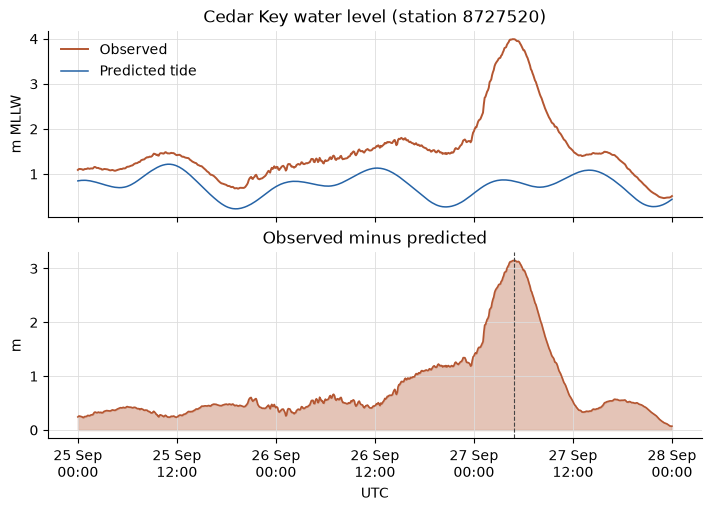

In [6]:
%matplotlib inline
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(7, 5), layout="constrained", sharex=True)
axes[0].plot(levels.index, levels["observed"], color="#b45631", linewidth=1.4, label="Observed")
axes[0].plot(
    levels.index, levels["predicted"], color="#2563a6", linewidth=1.1, label="Predicted tide"
)
axes[0].set(title="Cedar Key water level (station 8727520)", ylabel="m MLLW")
axes[0].legend(loc="upper left", frameon=False)
axes[1].fill_between(levels.index, 0, levels["residual"], color="#b45631", alpha=0.35)
axes[1].plot(levels.index, levels["residual"], color="#b45631", linewidth=1.2)
axes[1].axvline(peak_residual_at, color="#444444", linewidth=0.8, linestyle="--")
axes[1].set(title="Observed minus predicted", ylabel="m")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M", tz=UTC))
for ax in axes:
    ax.grid(color="#dddddd", linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].set_xlabel("UTC")
plt.show()

## 4. Place the peak on the best track

HURDAT2 holds one row per best-track point. Select Helene's 2024 track, compute
the great-circle distance from each point to the gauge, and find the landfall
record (`record_identifier` of `L`). Best-track positions are six-hourly plus
special landfall and peak-intensity points, so the storm's position at the
minute of peak residual is interpolated between the bracketing points. NOAA
lists station 8727520 at 29.135° N, 83.032° W.

In [7]:
GAUGE = (29.135, -83.032)


def distance_km(lat: float, lon: float) -> float:
    """Great-circle distance from the gauge to a point, in kilometres."""
    lat1, lon1, lat2, lon2 = map(math.radians, (GAUGE[0], GAUGE[1], lat, lon))
    half_dlat, half_dlon = (lat2 - lat1) / 2, (lon2 - lon1) / 2
    a = math.sin(half_dlat) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(half_dlon) ** 2
    return 2 * 6371.0 * math.asin(math.sqrt(a))


tracks = items["noaa:hurdat2"].open()
helene = tracks[(tracks["name"] == "HELENE") & (tracks["time"].dt.year == 2024)].copy()
assert len(helene) > 0, "the HURDAT2 revision should include the 2024 season"
helene["distance_km"] = [
    distance_km(lat, lon) for lat, lon in zip(helene["latitude"], helene["longitude"], strict=True)
]
near = (helene["time"] >= peak_residual_at - pd.Timedelta(hours=18)) & (
    helene["time"] <= peak_residual_at + pd.Timedelta(hours=6)
)
columns = ["time", "record_identifier", "status", "latitude", "longitude"]
columns += ["max_wind_kt", "min_pressure_mb", "distance_km"]
window = helene[near]
display(window[columns].assign(distance_km=window["distance_km"].round(1)))

landfalls = helene[helene["record_identifier"] == "L"]
landfall = landfalls.loc[landfalls["distance_km"].idxmin()]
before = helene[helene["time"] <= peak_residual_at].iloc[-1]
after = helene[helene["time"] >= peak_residual_at].iloc[0]
span = after["time"] - before["time"]
fraction = 0.0 if span == pd.Timedelta(0) else (peak_residual_at - before["time"]) / span
storm_lat = before["latitude"] + fraction * (after["latitude"] - before["latitude"])
storm_lon = before["longitude"] + fraction * (after["longitude"] - before["longitude"])
lag_hours = (peak_residual_at - landfall["time"]).total_seconds() / 3600
side = "east" if GAUGE[1] > storm_lon else "west"
winds = "onshore" if GAUGE[1] > storm_lon else "offshore"
print(
    f"Landfall record: {landfall['time']:%Y-%m-%d %H:%M} UTC at "
    f"{landfall['latitude']:.1f}N {abs(landfall['longitude']):.1f}W, "
    f"{landfall['max_wind_kt']:.0f} kt, {landfall['distance_km']:.0f} km from the gauge"
)
print(f"Peak residual came {lag_hours:+.1f} h relative to landfall")
print(
    f"Interpolated storm position at the peak: {storm_lat:.2f}N {abs(storm_lon):.2f}W, "
    f"{distance_km(storm_lat, storm_lon):.0f} km from the gauge"
)
print(f"The gauge lay {side} of the track, on the {winds}-wind side of a northward-moving storm")

,time,record_identifier,status,latitude,longitude,max_wind_kt,min_pressure_mb,distance_km
54956,2024-09-26 12:00:00+00:00,<NA>,HU,24.7,-85.8,85.0,963.0,564.3
54957,2024-09-26 18:00:00+00:00,<NA>,HU,26.6,-85.0,105.0,958.0,341.9
54958,2024-09-27 00:00:00+00:00,<NA>,HU,28.7,-84.3,120.0,941.0,132.6
54959,2024-09-27 03:10:00+00:00,L,HU,30.0,-83.7,120.0,939.0,115.9
54960,2024-09-27 05:00:00+00:00,R,HU,30.8,-83.5,95.0,947.0,190.5
54961,2024-09-27 06:00:00+00:00,<NA>,HU,31.3,-83.3,80.0,957.0,242.1
54962,2024-09-27 09:00:00+00:00,R,TS,32.9,-83.1,60.0,967.0,418.7


Landfall record: 2024-09-27 03:10 UTC at 30.0N 83.7W, 120 kt, 116 km from the gauge
Peak residual came +1.7 h relative to landfall
Interpolated storm position at the peak: 30.76N 83.51W, 186 km from the gauge
The gauge lay east of the track, on the onshore-wind side of a northward-moving storm


## What does it show?

Report the peak residual, the peak observed level, and their timing against
the landfall record. These are one gauge's verified six-minute values relative
to a prediction, not a regional surge height: nearby shorelines saw different
totals, waves add to what a stilling-well gauge records, and a residual also
contains pressure and wind setup that are not surge in the strict sense. The
best track is a post-season reanalysis, so its times and positions are
estimates too.

In [8]:
print(
    f"Helene added {peak['residual']:.2f} m above the predicted tide at Cedar Key, "
    f"peaking at {peak_residual_at:%H:%M} UTC on {peak_residual_at:%d %B %Y}."
)
print(
    f"The water stood {highest['observed']:.2f} m above MLLW at its highest, "
    f"{highest['residual']:.2f} m of which was residual."
)
print(
    f"The peak residual came {lag_hours:.1f} h after the best-track landfall point, "
    f"{landfall['distance_km']:.0f} km away."
)
print("Scope: one verified NOAA gauge, one harmonic prediction, one best-track revision.")

Helene added 3.15 m above the predicted tide at Cedar Key, peaking at 04:54 UTC on 27 September 2024.
The water stood 3.99 m above MLLW at its highest, 3.15 m of which was residual.
The peak residual came 1.7 h after the best-track landfall point, 116 km away.
Scope: one verified NOAA gauge, one harmonic prediction, one best-track revision.


## 5. Verify, and expect revisions

Verification is offline: it checks the manifest and cached bytes against the
lockfile. A repeat pull restores all three pinned assets from the cache.

None of the three sources is a fixed file. NOAA re-verifies observations,
updates a station's harmonic constituents behind its predictions, and replaces
the HURDAT2 file each season under a new name. Restoration then exits 4,
reports every asset whose bytes changed, and rewrites nothing. Accept the new
bytes for a named entry with `usdata pull dataset.yaml --update noaa:hurdat2`,
or with `pull(manifest, update=["noaa:hurdat2"])`, and rerun the analysis.

In [9]:
drift = verify(manifest)
assert not drift, drift
again = pull(manifest)
print(f"Verification passed: {not drift}")
print(f"Restored from lockfile: {again.from_lockfile}")
print(f"All assets came from cache: {all(value.from_cache for value in again.fetched)}")

Verification passed: True
Restored from lockfile: True
All assets came from cache: True
